# Spectral analysis II

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import statsmodels.api as sm

from utils import (
    get_figure, 
    time_plot, 
    plot_fft,
    moving_average_smoothing
)

## Task 1: Compare Different Tapering Windows

### 1.1 Window Functions Applied to Synthetic Data

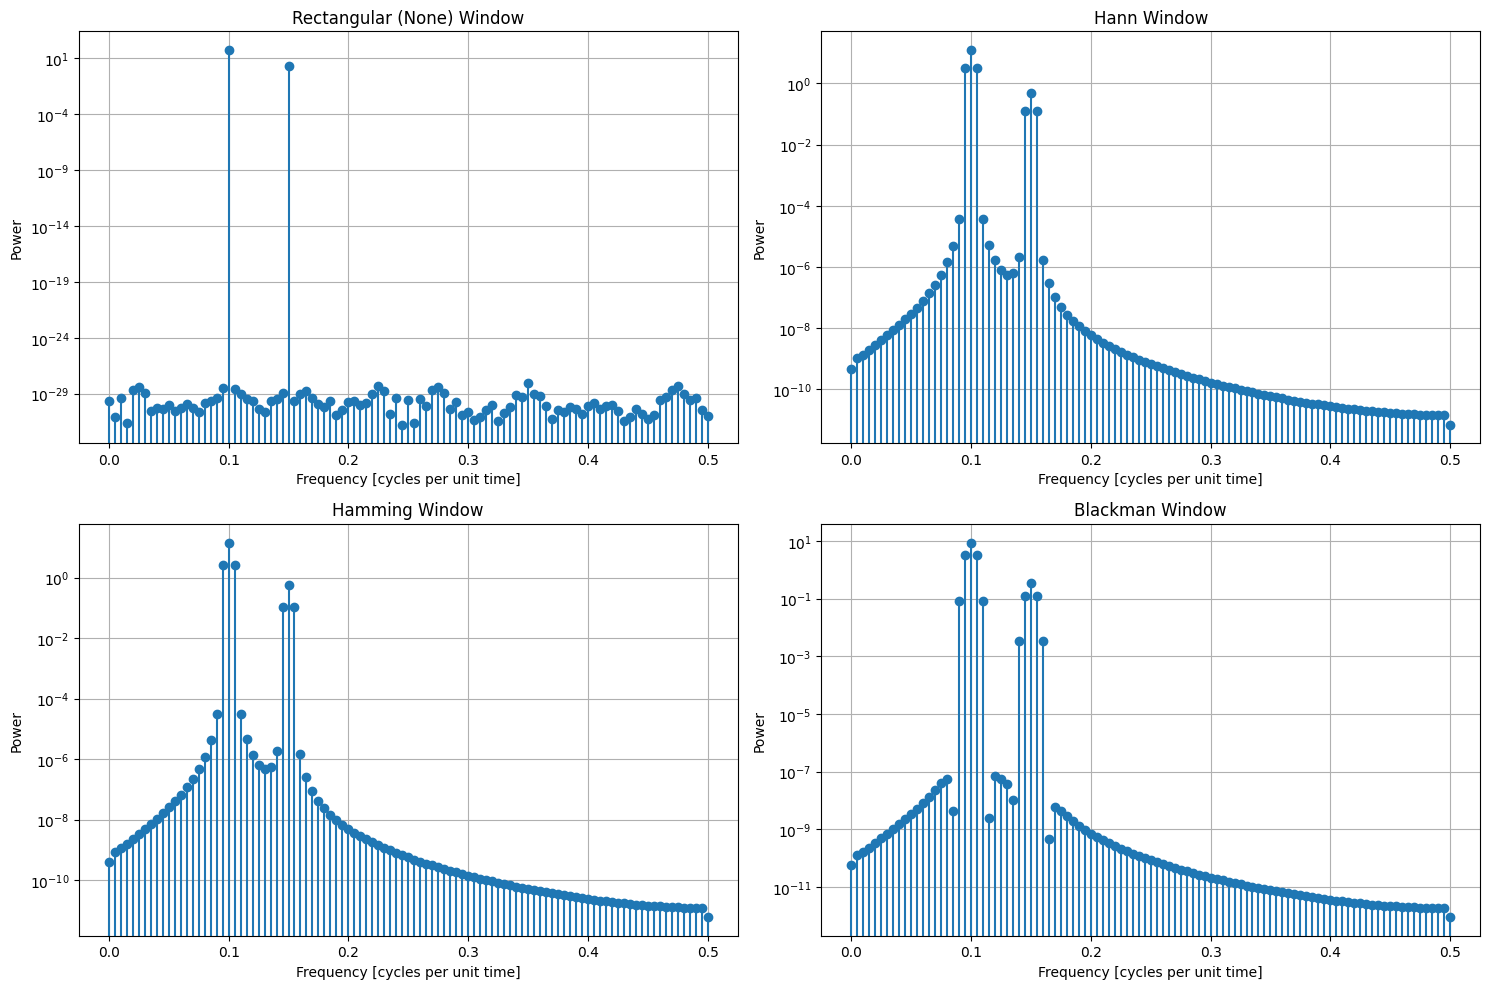

In [51]:
n = 200
t = np.arange(n)
x_t = 10 * np.sin(2 * np.pi * 0.1 * t) + 2 * np.sin(2 * np.pi * 0.15 * t) 

windows = {
    "Rectangular (None)": np.ones(n),
    "Hann": signal.windows.hann(n),
    "Hamming": signal.windows.hamming(n),
    "Blackman": signal.windows.blackman(n)
}

fig, axs = get_figure(nrows=2, ncols=2, figsize=(15, 10))

for i, (name, win) in enumerate(windows.items()):
    tapered_x = x_t * win
    
    plot_fft(
        axs[i], 
        pd.Series(tapered_x), 
        periodogram=True, 
        log_scale=True
    )
    
    axs[i].set_title(f"{name} Window")
    
fig.tight_layout()

**Interpretation:**
- **Rectangular:** Sharpest peaks (narrowest main lobe) but highest sidelobes → most spectral leakage.
- **Hann:** Good balance between main lobe width and sidelobe suppression. Default choice for most applications.
- **Hamming:** Looks identical to Hann.
- **Blackman:** Lowest sidelobes but widest main lobe → best for high dynamic range signals where frequency resolution is less critical.

### 1.2 Comparing Window Properties: Main Lobe Width & Sidelobe Attenuation

Visualizing how energy spreads around peaks (main lobe width) and how frequencies are attenuated (sidelobe level)

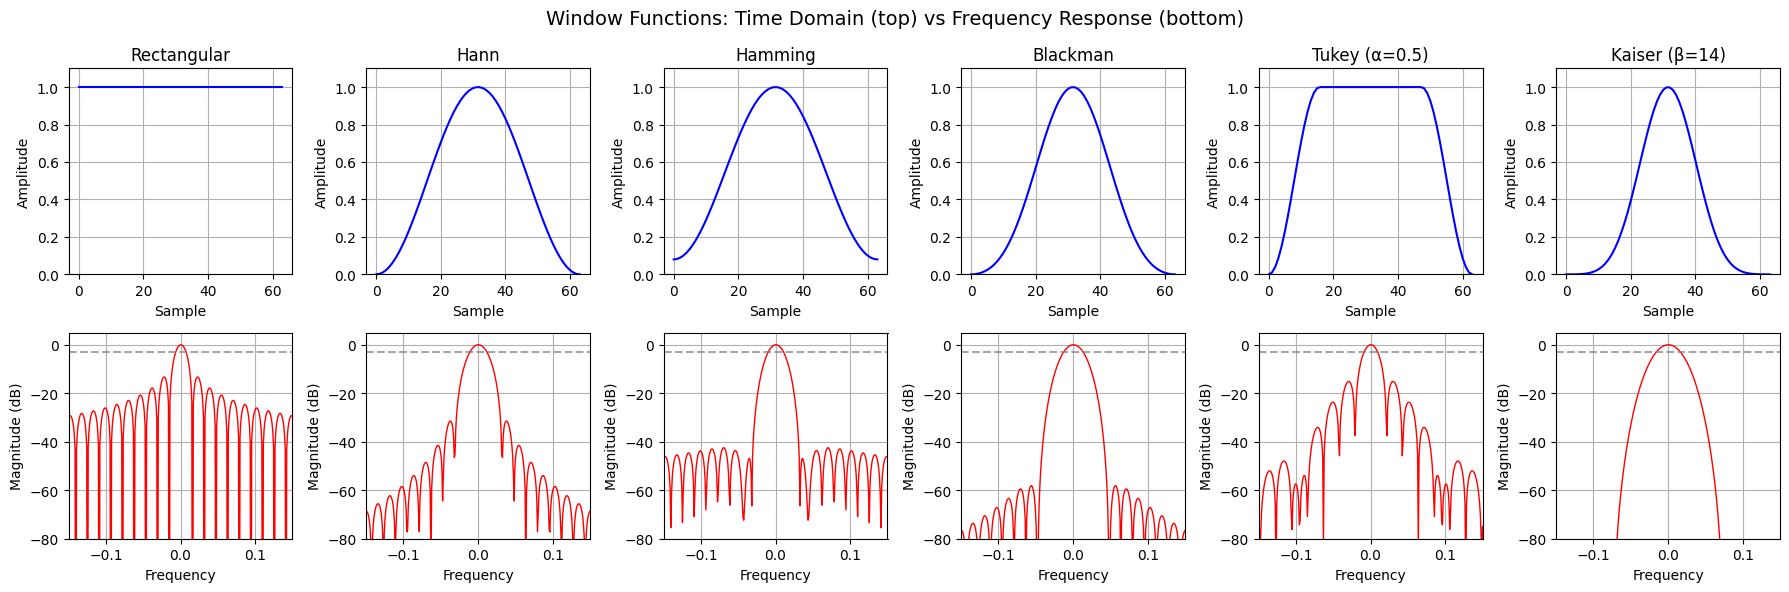

In [42]:
n_win = 64
windows_detail = {
    "Rectangular": np.ones(n_win),
    "Hann": signal.windows.hann(n_win),
    "Hamming": signal.windows.hamming(n_win),
    "Blackman": signal.windows.blackman(n_win),
    "Tukey (α=0.5)": signal.windows.tukey(n_win, alpha=0.5),
    "Kaiser (β=14)": signal.windows.kaiser(n_win, beta=14)
}

fig, axs = plt.subplots(2, len(windows_detail), figsize=(18, 6))

for i, (name, win) in enumerate(windows_detail.items()):
    axs[0, i].plot(win, 'b-', linewidth=1.5)
    axs[0, i].set_title(f"{name}")
    axs[0, i].set_xlabel("Sample")
    axs[0, i].set_ylabel("Amplitude")
    axs[0, i].set_ylim(0, 1.1)
    axs[0, i].grid(True)
    
    n_fft = 1024
    freq_response = np.fft.fft(win, n_fft)
    freq_response = np.fft.fftshift(freq_response)
    freq_response_db = 20 * np.log10(np.abs(freq_response) / np.max(np.abs(freq_response)) + 1e-10)
    freqs = np.linspace(-0.5, 0.5, n_fft)
    
    axs[1, i].plot(freqs, freq_response_db, 'r-', linewidth=1)
    axs[1, i].set_xlim(-0.15, 0.15)
    axs[1, i].set_ylim(-80, 5)
    axs[1, i].set_xlabel("Frequency")
    axs[1, i].set_ylabel("Magnitude (dB)")
    axs[1, i].axhline(y=-3, color='gray', linestyle='--', alpha=0.7, label='-3dB')
    axs[1, i].grid(True)

fig.suptitle("Window Functions: Time Domain (top) vs Frequency Response (bottom)", fontsize=14)
fig.tight_layout()
plt.show()

Interpretation:
- Main lobe width: Determines frequency resolution. Narrower = better separation of nearby frequencies.
- Sidelobe level: Determines leakage. Lower sidelobes = less energy "leaking" from strong peaks to other frequencies.
- Tukey (α=0.5): Compromise between rectangular and Hann, tapers only the edges.
- Kaiser (β=14): Adjustable trade-off via β parameter. High β gives very low sidelobes.

## Task 2: Compare Different Linear Filters

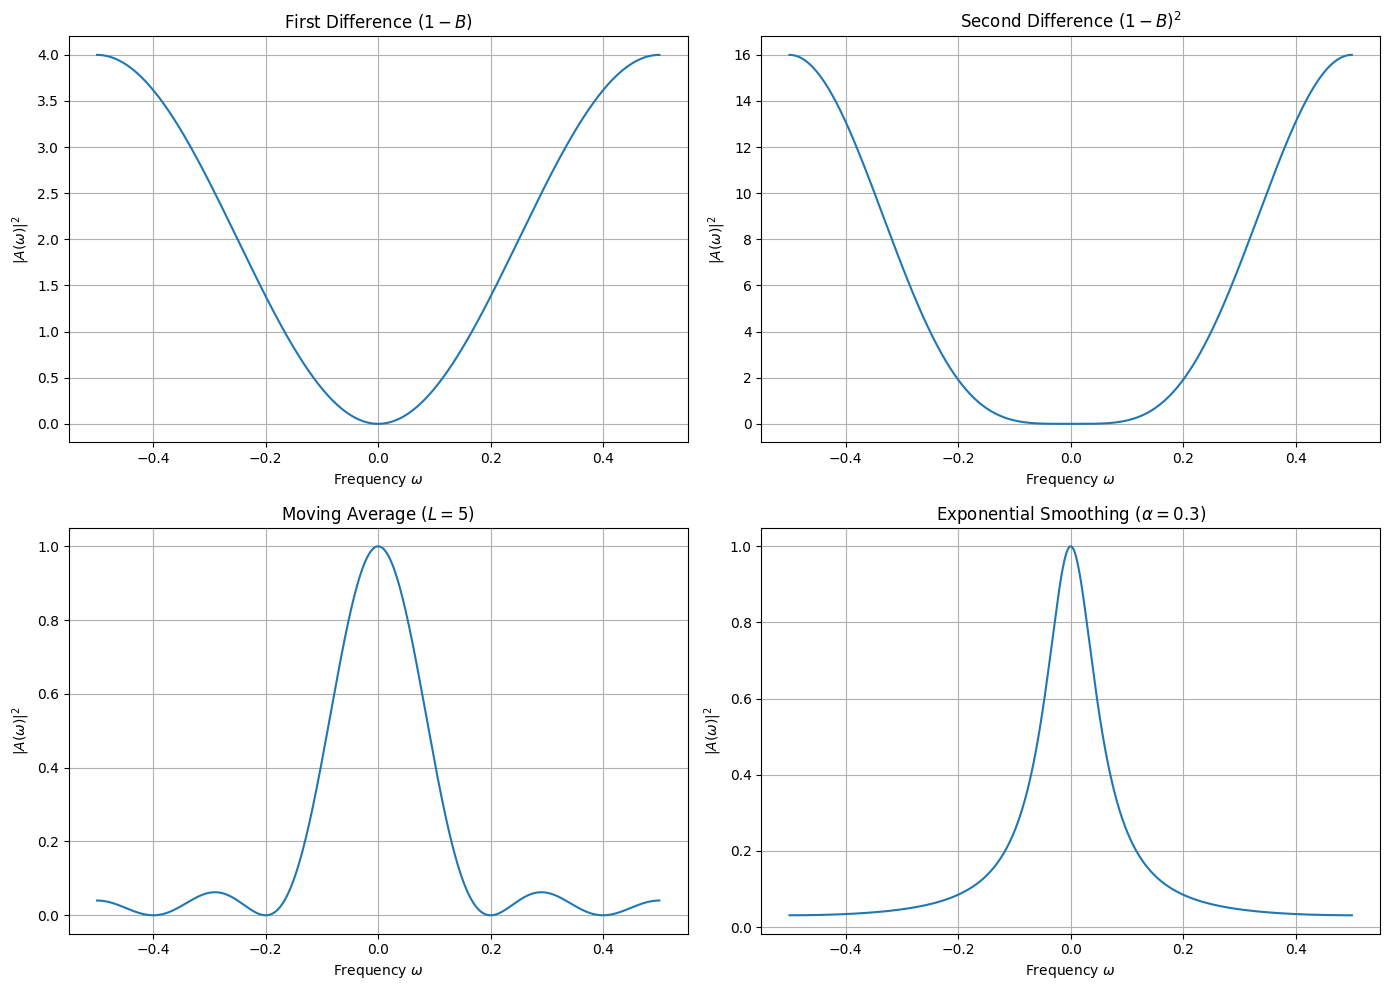

In [49]:
frequencies = np.linspace(-0.5, 0.5, 1000)

# First Difference (1-B)
diff_response = 2 * (1 - np.cos(2 * np.pi * frequencies))

# Second Difference (1-B)^2 
second_diff_response = (2 * (1 - np.cos(2 * np.pi * frequencies)))**2

# Moving Average
L = 5
ma_response = (np.sin(np.pi * frequencies * L) / (L * np.sin(np.pi * frequencies + 1e-10)))**2

# Exponential Smoothing
alpha = 0.3
exp_response = alpha**2 / (1 - 2*(1-alpha)*np.cos(2*np.pi*frequencies) + (1-alpha)**2)

fig, axs = get_figure(nrows=2, ncols=2, figsize=(14, 10))

time_plot(frequencies, diff_response, ax=axs[0], 
          title="First Difference $(1-B)$", 
          xlabel=r"Frequency $\omega$", 
          ylabel=r"$|A(\omega)|^2$")

time_plot(frequencies, second_diff_response, ax=axs[1], 
          title="Second Difference $(1-B)^2$", 
          xlabel=r"Frequency $\omega$", 
          ylabel=r"$|A(\omega)|^2$")

time_plot(frequencies, ma_response, ax=axs[2], 
          title=f"Moving Average ($L={L}$)", 
          xlabel=r"Frequency $\omega$", 
          ylabel=r"$|A(\omega)|^2$")

time_plot(frequencies, exp_response, ax=axs[3], 
          title=f"Exponential Smoothing ($\\alpha={alpha}$)", 
          xlabel=r"Frequency $\omega$", 
          ylabel=r"$|A(\omega)|^2$")

fig.tight_layout()
plt.show()

**Interpretation:**

1. **First Difference $(1-B)$:** High-pass filter with zero at ω=0. Removes linear trend.
   - *Use case:* Data with linear trends (e.g., prices, cumulative counts).

2. **Second Difference $(1-B)^2$:** Stronger high-pass filter with double zero at ω=0. Removes trend and curvature.
   - *Use case:* Data with quadratic/accelerating trends (e.g., growth curves).

3. **Moving Average (L=5):** Low-pass filter averaging L points. Zeros at 1/L, 2/L, etc. preserves trend, removes high frequencies.
   - *Use case:* Noisy data where underlying trend needs to be preserved.

4. **Exponential Smoothing:** Weighted low-pass filter. Has adaptive smoothing where recent values matter more.
   - *Use case:* Non-stationary data where recent observations carry more weight.

## Task 3: Apply Tapering, Smoothing, and Filtering to Real-World Data

Using the AirPassengers dataset

Data length: 144 observations
Sample spacing: 0.08333333333333333 year
Nyquist frequency: 6.0 cycles per year


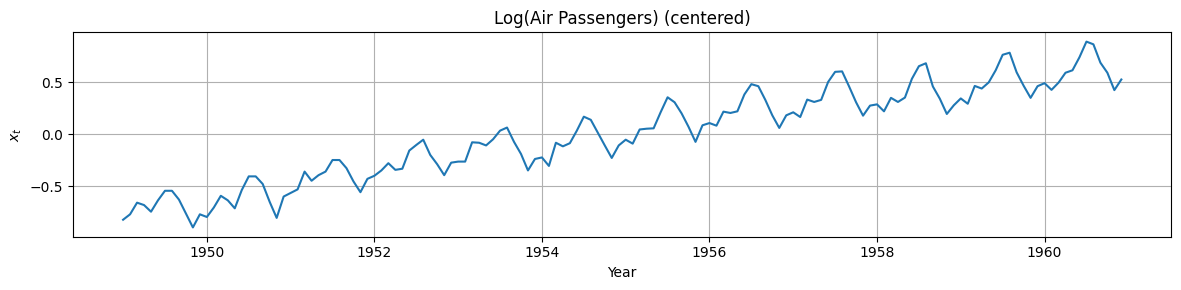

In [39]:
data = sm.datasets.get_rdataset('AirPassengers').data
passengers_series = pd.Series(data['value'].values, index=data['time']).astype(float)

log_passengers = np.log(passengers_series)
data_eval = log_passengers - log_passengers.mean()

label = "Log(Air Passengers)"
sample_spacing = 1/12
spacing_name = "year"

print(f"Data length: {len(data_eval)} observations")
print(f"Sample spacing: {sample_spacing} {spacing_name}")
print(f"Nyquist frequency: {1/(2*sample_spacing)} cycles per {spacing_name}")

fig, axs = get_figure(figsize=(12, 3))
time_plot(data_eval.index, data_eval.values, ax=axs[0], title=f"{label} (centered)", xlabel="Year")
plt.show()

### 3.1 Raw Periodogram in Linear vs Log Scale

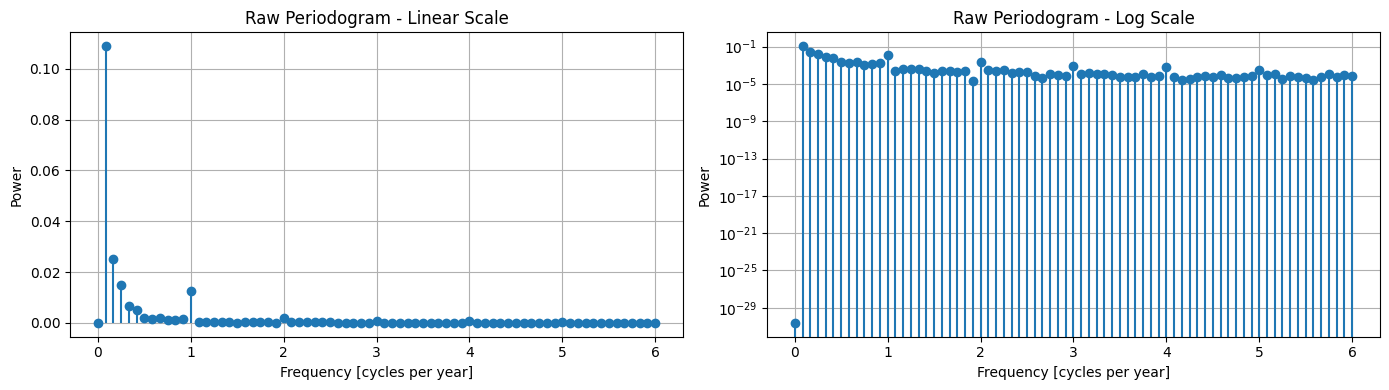

In [45]:
fig, axs = get_figure(nrows=1, ncols=2, figsize=(14, 4))

plot_fft(axs[0], data_eval, sample_spacing, spacing_name, periodogram=True)
axs[0].set_title(f"Raw Periodogram - Linear Scale")

plot_fft(axs[1], data_eval, sample_spacing, spacing_name, periodogram=True, log_scale=True)
axs[1].set_title(f"Raw Periodogram - Log Scale")

fig.tight_layout()
plt.show()

**Interpretation:**
- **Linear scale:** Dominated by the annual peak at 1 cycle/year. Other features invisible due to scale.
- **Log scale (dB):** Reveals harmonics at 1, 2, 3, 4 cycles/year and the noise floor.
- **Dynamic range** = ratio of max to min power. High dynamic range → use log scale.
- **Annual seasonality** clearly visible as the dominant peak at 1 cycle/year.

### 3.2 Effect of Different Tapering Windows

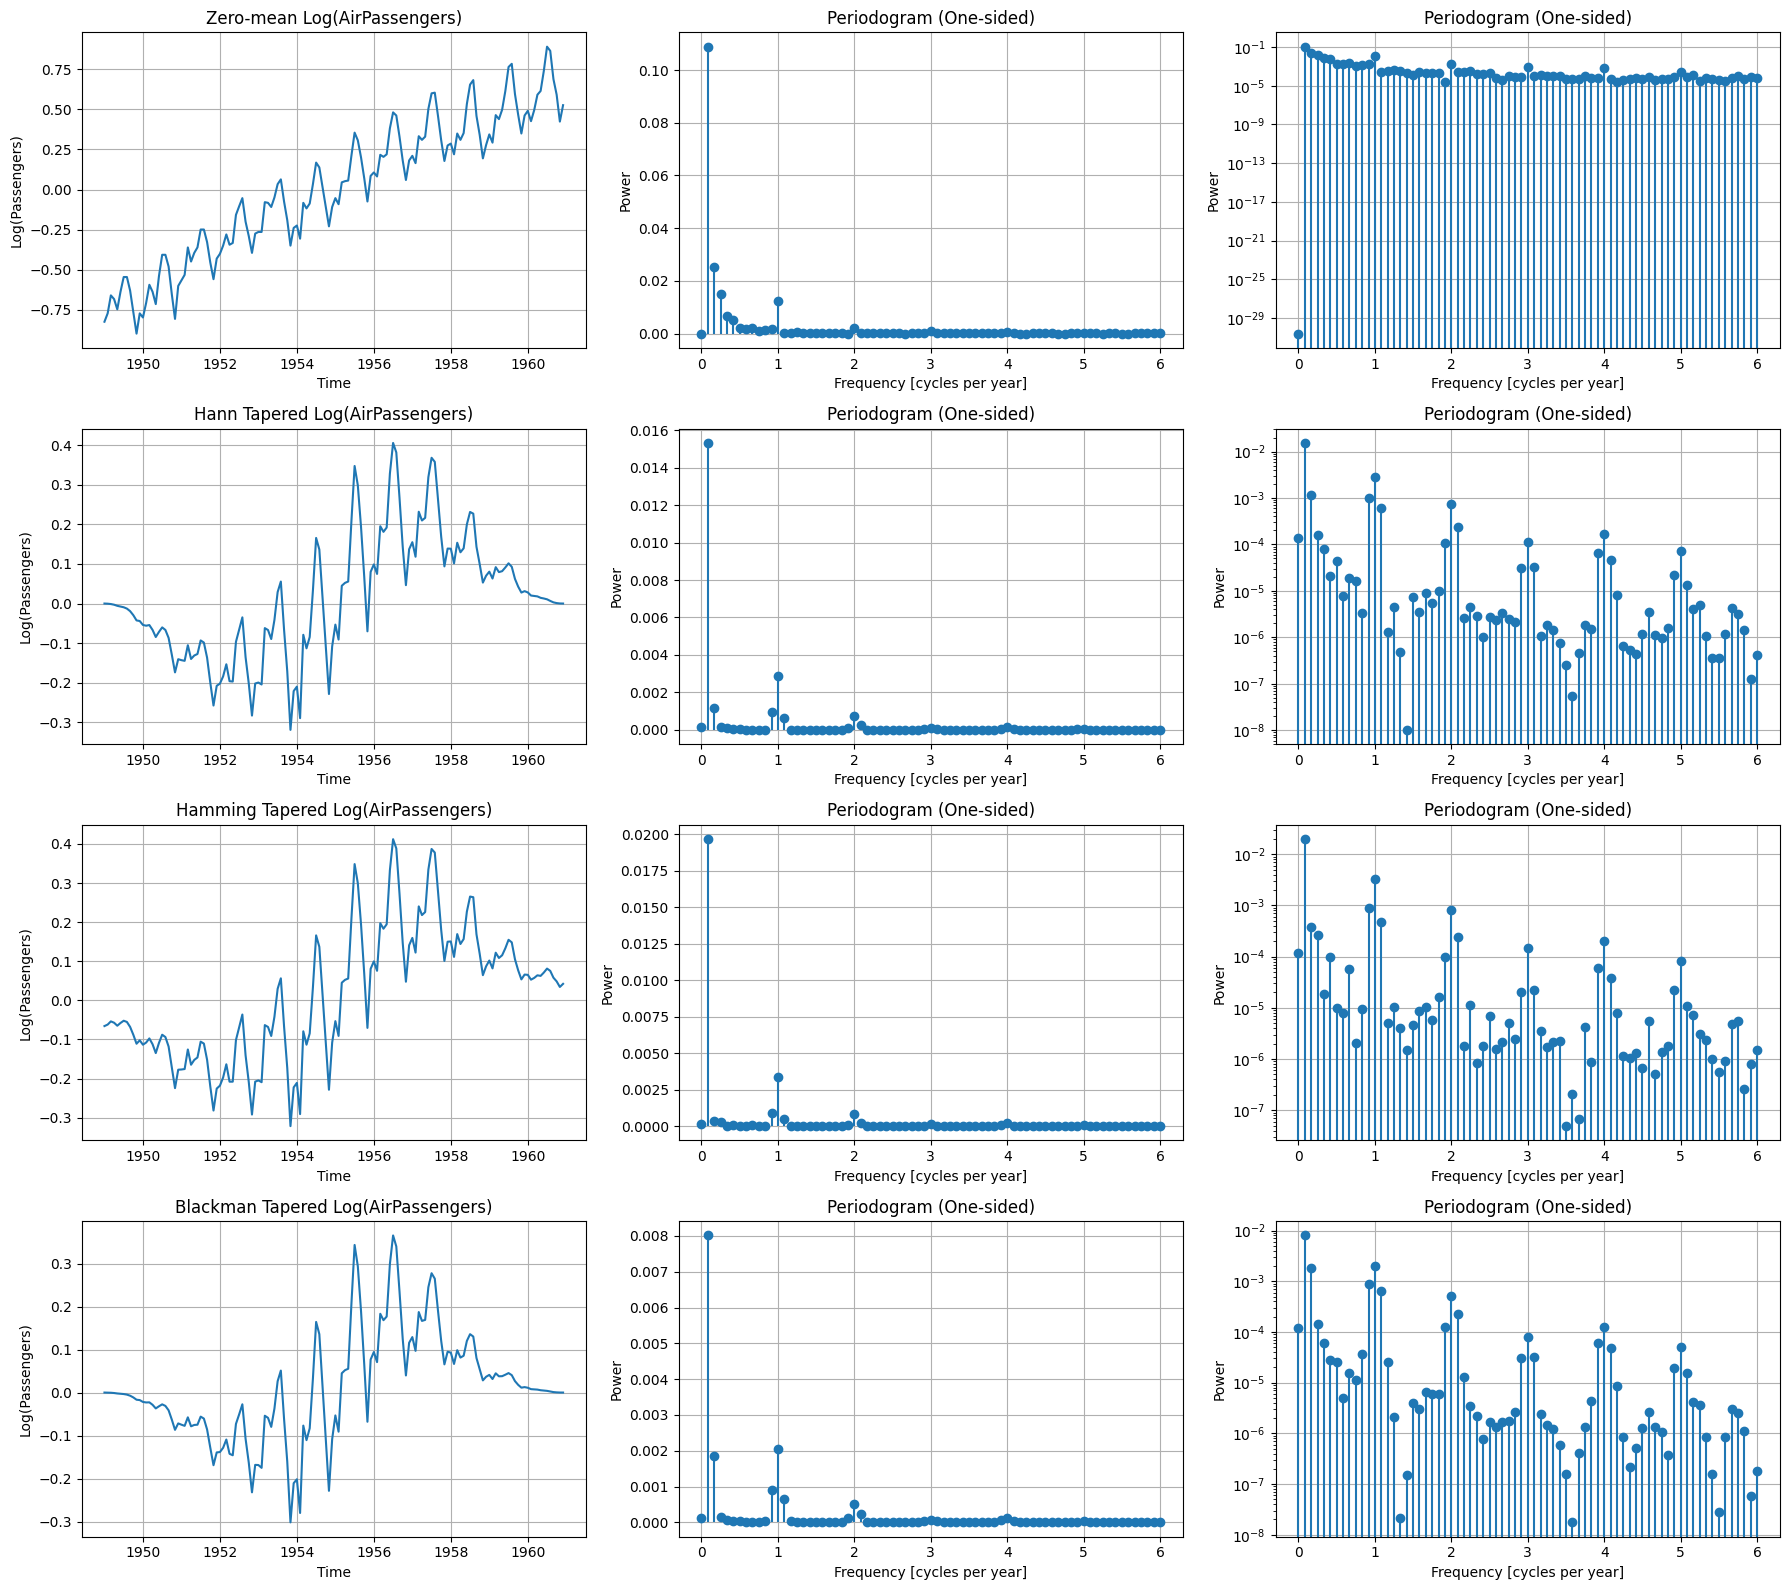

In [52]:
tapered_hann = data_eval * signal.windows.hann(len(data_eval))
tapered_hamming = data_eval * signal.windows.hamming(len(data_eval))
tapered_blackman = data_eval * signal.windows.blackman(len(data_eval))

fig, axs = get_figure(nrows=4, ncols=3, figsize=(18, 16))

time_plot(x=data_eval.index, y=data_eval, title='Zero-mean Log(AirPassengers)', xlabel='Time', ylabel='Log(Passengers)', ax=axs[0])
plot_fft(axs[1], data_eval, sample_spacing, spacing_name, periodogram=True)
plot_fft(axs[2], data_eval, sample_spacing, spacing_name, periodogram=True, log_scale=True)

time_plot(x=tapered_hann.index, y=tapered_hann, title='Hann Tapered Log(AirPassengers)', xlabel='Time', ylabel='Log(Passengers)', ax=axs[3])
plot_fft(axs[4], tapered_hann, sample_spacing, spacing_name, periodogram=True)
plot_fft(axs[5], tapered_hann, sample_spacing, spacing_name, periodogram=True, log_scale=True)

time_plot(x=tapered_hamming.index, y=tapered_hamming, title='Hamming Tapered Log(AirPassengers)', xlabel='Time', ylabel='Log(Passengers)', ax=axs[6])
plot_fft(axs[7], tapered_hamming, sample_spacing, spacing_name, periodogram=True)
plot_fft(axs[8], tapered_hamming, sample_spacing, spacing_name, periodogram=True, log_scale=True)

time_plot(x=tapered_blackman.index, y=tapered_blackman, title='Blackman Tapered Log(AirPassengers)', xlabel='Time', ylabel='Log(Passengers)', ax=axs[9])
plot_fft(axs[10], tapered_blackman, sample_spacing, spacing_name, periodogram=True)
plot_fft(axs[11], tapered_blackman, sample_spacing, spacing_name, periodogram=True, log_scale=True)

fig.tight_layout()

**Interpretation:**

- **Top row (raw):** Periodogram with rectangular window → spectral leakage from edge discontinuities.
- **Second row (Hann):** Reduces sidelobe leakage, cleaner baseline between peaks.
- **Third row (Hamming):** Similar to Hann.
- **Bottom row (Blackman):** Even lower sidelobes than Hann/Hamming, but slightly wider main lobe → best for high dynamic range.
- **Effect on AirPassengers:** Subtle improvement because the dynamic range is moderate.

### 3.3 Determining Appropriate Smoothing Strength

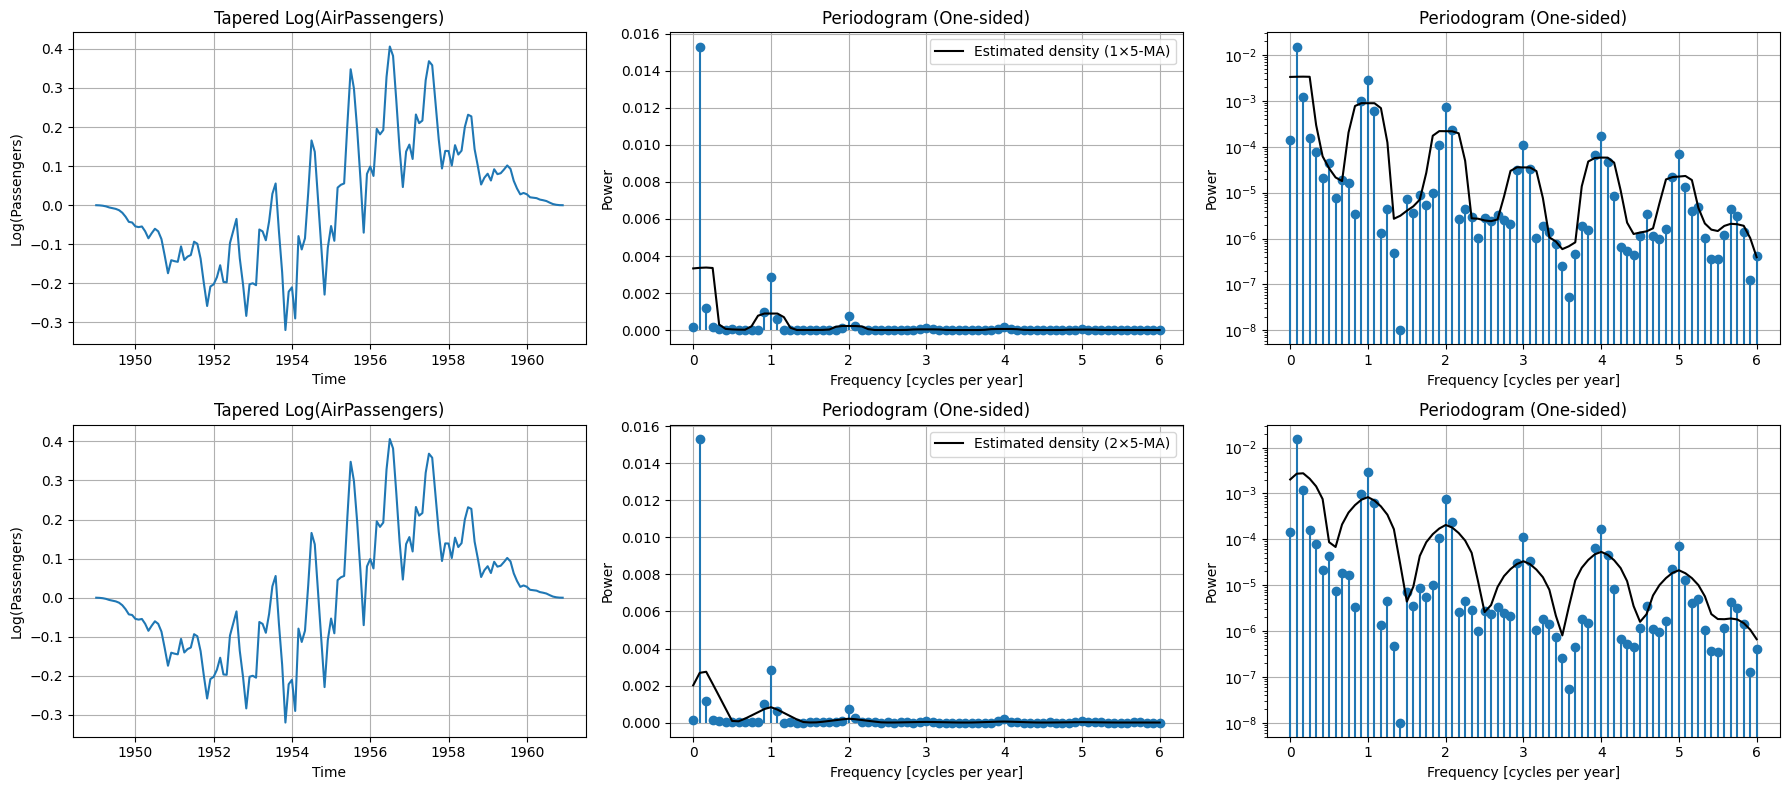

In [47]:
smoothed_data = data_eval * signal.windows.hann(len(data_eval))
smoothing_window_percent = 0.08

fig, axs = get_figure(nrows=2, ncols=3, figsize=(18, 8))

time_plot(x=smoothed_data.index, y=smoothed_data, title='Tapered Log(AirPassengers)', xlabel='Time', ylabel='Log(Passengers)', ax=axs[0])
plot_fft(axs[1], smoothed_data, sample_spacing, spacing_name, periodogram=True,
         show_estimated_density=True, smoothing_iteration=1, smoothing_window_percent=smoothing_window_percent)
plot_fft(axs[2], smoothed_data, sample_spacing, spacing_name, periodogram=True, log_scale=True,
         show_estimated_density=True, smoothing_iteration=1, smoothing_window_percent=smoothing_window_percent)

time_plot(x=smoothed_data.index, y=smoothed_data, title='Tapered Log(AirPassengers)', xlabel='Time', ylabel='Log(Passengers)', ax=axs[3])
plot_fft(axs[4], smoothed_data, sample_spacing, spacing_name, periodogram=True,
         show_estimated_density=True, smoothing_iteration=2, smoothing_window_percent=smoothing_window_percent)
plot_fft(axs[5], smoothed_data, sample_spacing, spacing_name, periodogram=True, log_scale=True,
         show_estimated_density=True, smoothing_iteration=2, smoothing_window_percent=smoothing_window_percent)

axs[1].legend()
axs[4].legend()
fig.tight_layout()

**Interpretation - Smoothing Effect:**

- **1× smoothing:** Light smoothing: periodogram still noisy but structure visible.
- **2× smoothing:** Heavier smoothing: cleaner spectral density estimate.

**Bias-variance trade-off:**
- More smoothing → lower variance (less noisy) but higher bias (peaks smeared)
- Less smoothing → higher variance (noisy) but lower bias (sharper peaks)

### 3.4 Effect of Different Filters

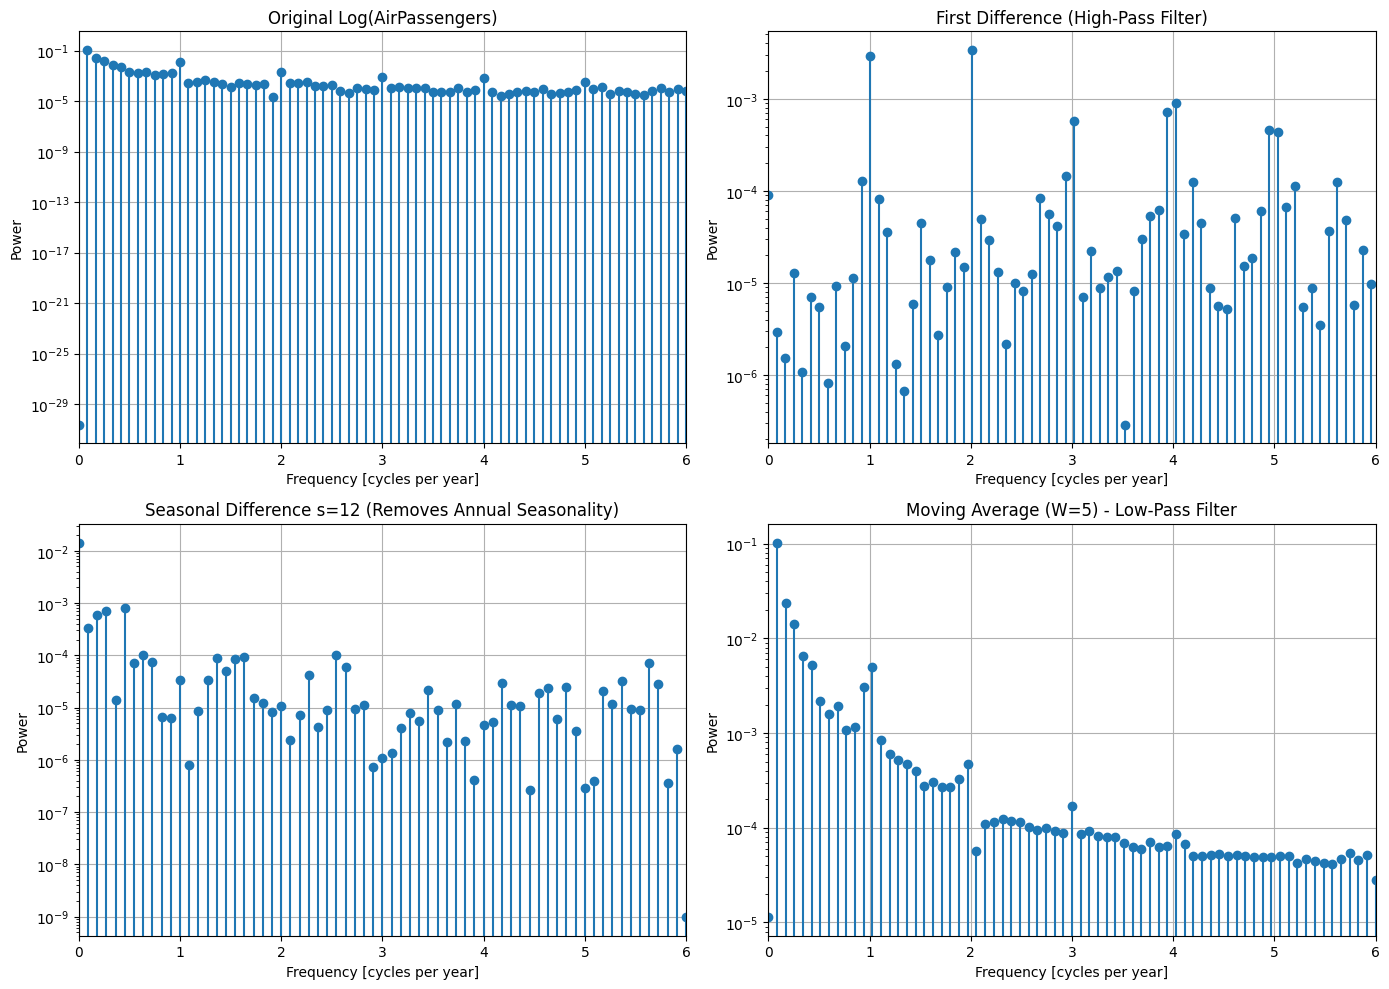

In [19]:
fig, axs = get_figure(nrows=2, ncols=2, figsize=(14, 10))

plot_fft(axs[0], data_eval, sample_spacing, spacing_name, periodogram=True, log_scale=True)
axs[0].set_title("Original Log(AirPassengers)")
axs[0].set_xlim(0, 6)

data_diff = data_eval.diff().dropna()
plot_fft(axs[1], data_diff, sample_spacing, spacing_name, periodogram=True, log_scale=True)
axs[1].set_title("First Difference (High-Pass Filter)")
axs[1].set_xlim(0, 6)

data_seas_diff = data_eval.diff(12).dropna()
plot_fft(axs[2], data_seas_diff, sample_spacing, spacing_name, periodogram=True, log_scale=True)
axs[2].set_title("Seasonal Difference s=12 (Removes Annual Seasonality)")
axs[2].set_xlim(0, 6)

window_size = 5
_, _, data_ma = moving_average_smoothing(data_eval.values, window_size=window_size, mode='valid')
data_ma_series = pd.Series(data_ma)
plot_fft(axs[3], data_ma_series, sample_spacing, spacing_name, periodogram=True, log_scale=True)
axs[3].set_title(f"Moving Average (W={window_size}) - Low-Pass Filter")
axs[3].set_xlim(0, 6)

fig.tight_layout()
plt.show()

The First Difference (High-Pass Filter) successfully removes the low-frequency trend, while the Seasonal Difference ($\text{s}=12$ ) specifically eliminates the power peak associated with annual seasonality. In contrast, the Moving Average (Low-Pass Filter) dampens the high-frequency noise but also slightly reduces the magnitude of the primary seasonal peaks.